# QTCAD M09 g-tensor — Result Analysis (심화판)

- Atoms 4 — FD-SOI 소자에서 g-tensor 계산 (`g_tensor.py`)
- Device 10 — 자기장 하에서 spin-orbit coupling 효과 (`holes_soc_B.py`)

이 노트북은 두 튜토리얼이 저장한 결과를 불러와 분석합니다. `g_tensor.py`는 FD-SOI 소자
아래 플런저 게이트 영역의 원자 구조(76,917개 원자, 원래 튜토리얼의 269,934개에서
메모리 문제로 축소 — `notes.md` 참고)에서 tight-binding Schrödinger 방정식을 풀어
바닥/들뜬 상태의 g-tensor와 면내 자기장에 대한 spin-splitting 비등방성을 계산합니다.
`holes_soc_B.py`는 작은 GaAs 박스(60x60x3nm)에서 수직 자기장을 걸고 spin-orbit
coupling(SOC)을 켰을 때/껐을 때 정공 에너지 준위가 어떻게 갈라지는지 비교합니다.

**이 노트북에서 실제로 수행한 분석 (요약)**
- 두 소자 각각의 **스케매틱**(FD-SOI 게이트 스택 + TB 영역 위치, GaAs 박스) (0절)
- **Zeeman Hamiltonian과 g-tensor의 정의식**을 명시 (1절)
- 면내 각도별 spin-splitting에서 **등방성/비등방성을 정량화** (2절)
- 실행 로그에서 g-tensor 행렬을 파싱해 **대각/비대각 성분의 물리적 의미** 해석 (3절)
- `holes_soc_B.py`의 **$k_z^2$-SOC Hamiltonian 형태**를 명시하고 수치-해석 비교 (4-5절)
- 모든 그림·표를 `output/analysis_exports/`에 저장 (6절)

---
## 📚 참고 문서
- **QTCAD 공식 튜토리얼** — Atoms 4: Computing g-tensors in an FD-SOI device
  https://docs.nanoacademic.com/qtcad/tutorials/atoms/g_tensor/
- **QTCAD 공식 튜토리얼** — Device 10: Including spin-orbit coupling and magnetic effects in a simulation
  https://docs.nanoacademic.com/qtcad/tutorials/device/holes_soc_B/
- **QTCAD 문서 포털**: https://docs.nanoacademic.com/qtcad/
- 소스 스크립트: `g_tensor.py`, `holes_soc_B.py` (M09/Reference)
---

**Base directory**

`C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M09. g-tensor\Reference`

목차:
0. 두 소자의 스케매틱 + 파라미터 선택 의도
1. Zeeman Hamiltonian과 g-tensor의 정의
2. 면내 spin-splitting 비등방성 정량화
3. g-tensor 행렬 — 대각/비대각 성분 해석
4. $k_z^2$-SOC Hamiltonian과 SOC 유무 에너지 비교
5. $\langle k_z^2\rangle$ — 수치 vs 해석값
6. 최종 요약


In [1]:
# [동작] 기본 패키지 및 경로 설정
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.image as mpimg
from IPython.display import display

BASE_DIR = Path(
    r"C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M09. g-tensor\Reference"
)
OUTPUT_DIR = BASE_DIR / "output"
EXPORT_DIR = OUTPUT_DIR / "analysis_exports"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

FILE_G_TXT = OUTPUT_DIR / "in_plane_g.txt"
FILE_E_NOSOC = OUTPUT_DIR / "hole_energies_vs_B.txt"
FILE_E_SOC = OUTPUT_DIR / "hole_energies_withSOC_vs_B.txt"
FILE_KZ2_TXT = OUTPUT_DIR / "kz2_holes.txt"

ct_e = 1.602176634e-19
mu_B = 9.2740100783e-24  # Bohr magneton (J/T)

print("BASE_DIR  :", BASE_DIR)
assert BASE_DIR.exists(), f"Base directory가 없습니다:\n{BASE_DIR}"
print("\n[OK] 기본 경로 확인 완료")


BASE_DIR  : C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M09. g-tensor\Reference

[OK] 기본 경로 확인 완료


In [2]:
# [점검] 파일 inventory
expected_files = {"in_plane_g.txt": FILE_G_TXT, "hole_energies_vs_B.txt": FILE_E_NOSOC,
                  "hole_energies_withSOC_vs_B.txt": FILE_E_SOC, "kz2_holes.txt": FILE_KZ2_TXT}
rows = []
for label, path in expected_files.items():
    rows.append({"file": label, "exists": path.exists(),
                "size_B": path.stat().st_size if path.exists() else np.nan})
inventory_df = pd.DataFrame(rows)
display(inventory_df)
missing = inventory_df.loc[~inventory_df["exists"], "file"].tolist()
print("\n[주의] 없는 파일:" if missing else "\n[OK] 분석 대상 파일이 모두 존재합니다.", missing or "")


,file,exists,size_B
0,in_plane_g.txt,True,904
1,hole_energies_vs_B.txt,True,1656
2,hole_energies_withSOC_vs_B.txt,True,1656
3,kz2_holes.txt,True,260



[OK] 분석 대상 파일이 모두 존재합니다. 


## 0. 두 소자의 스케매틱 + 파라미터 선택 의도

**(a) g_tensor.py**: M03/M16과 같은 FD-SOI 이중양자점 메시(`refined_dqdfdsoi.msh`) 위,
plunger_gate_1 아래쪽 작은 상자 영역(x: ±120Å, y: -220~-130Å, z: -60~10Å)에만 원자
구조를 올립니다 — 전체 소자를 원자 단위로 다루면 계산이 불가능할 정도로 커지므로, 실제
전자가 머무는 dot 영역만 TB로 계산합니다.

**(b) holes_soc_B.py**: 60x60x3nm GaAs 박스 하나(`box.geo`) — 얇은 z방향(3nm)이 강한
양자우물 구속을 만들어, 2차원 정공 가스에 가까운 상황을 모사합니다.

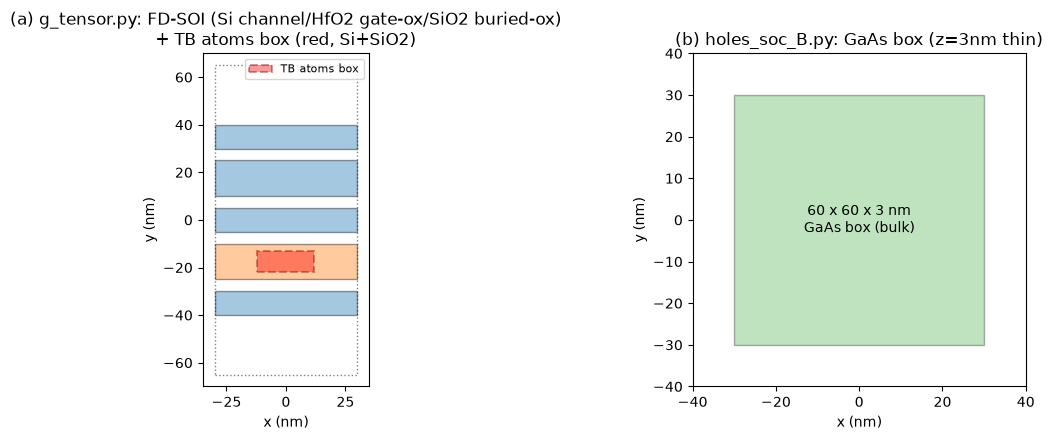

,parameter,intent
0,"TB box x:±120, y:-220~-130, z:-60~10 Å (76,917...","원래 튜토리얼(269,934원자, x:±200,y:-250~-100,z:-80~10..."
1,energy_target = 0.04*e (eigensolver shift-inve...,바닥상태 근처 에너지를 미리 알고 shift-invert 고유값 솔버가 그 근방에서...
2,"box.geo: 60x60x3 nm, Lz=3nm",5절에서 비교할 해석적 (π/Lz)² 값을 의미 있게 만들기 위해 충분히 얇은 z ...
3,"beta = 82*e*A^3 (SOC 결합상수), B_vec: 0~10T 6점","문헌값 결합상수(튜토리얼 기본값)로 SOC 세기를 고정하고, 자기장만 스윕해 SOC..."


In [3]:
# [실험] (a) g_tensor.py의 FD-SOI 스케매틱 + TB 상자 위치
domain_width, channel_width = 60.0, 40.0
gaps = [5.0] * 6
barrier_len, plunger_len, sd_len = 10.0, 15.0, 20.0
channel_len = sum(gaps) + 3 * barrier_len + 2 * plunger_len
domain_len = 2 * sd_len + channel_len
temp = -channel_len / 2 + gaps[0]
lens = [barrier_len, plunger_len, barrier_len, plunger_len, barrier_len]
gap_idx = [1, 2, 3, 4, 5]
names = ["barrier_gate_1", "plunger_gate_1", "barrier_gate_2", "plunger_gate_2", "barrier_gate_3"]
segs = []
for name, L, gi in zip(names, lens, gap_idx):
    segs.append((name, temp, temp + L)); temp = temp + gaps[gi] + L
p1_y0, p1_y1 = [s for s in segs if s[0] == "plunger_gate_1"][0][1:]

fig, axs = plt.subplots(1, 2, figsize=(13, 4.5))
ax = axs[0]
ax.add_patch(mpatches.Rectangle((-domain_width/2, -domain_len/2), domain_width, domain_len,
                                fill=False, ls=":", ec="0.5"))
for name, y0, y1 in segs:
    ax.add_patch(mpatches.Rectangle((-domain_width/2, y0), domain_width, y1 - y0,
                                    fc="tab:orange" if name=="plunger_gate_1" else "tab:blue",
                                    alpha=0.4, ec="k"))
# TB atoms box: x +-12nm, y -22~-13nm (converted from Angstrom)
tb_x, tb_y = 24.0, 9.0  # width, height in nm (120Å*2=24nm box width, 220-130=90Å=9nm)
ax.add_patch(mpatches.Rectangle((-tb_x/2, -22.0), tb_x, tb_y, fc="red", alpha=0.4,
                                ec="darkred", ls="--", lw=1.5, label="TB atoms box"))
ax.set_xlim(-domain_width/2-5, domain_width/2+5); ax.set_ylim(-domain_len/2-5, domain_len/2+5)
ax.set_aspect("equal"); ax.set_xlabel("x (nm)"); ax.set_ylabel("y (nm)")
ax.set_title("(a) g_tensor.py: FD-SOI (Si channel/HfO2 gate-ox/SiO2 buried-ox)\n+ TB atoms box (red, Si+SiO2)")
ax.legend(fontsize=8)

ax2 = axs[1]
ax2.add_patch(mpatches.Rectangle((-30, -30), 60, 60, fc="tab:green", alpha=0.3, ec="k"))
ax2.text(0, 0, "60 x 60 x 3 nm\nGaAs box (bulk)", ha="center", va="center", fontsize=10)
ax2.set_xlim(-40, 40); ax2.set_ylim(-40, 40)
ax2.set_aspect("equal"); ax2.set_xlabel("x (nm)"); ax2.set_ylabel("y (nm)")
ax2.set_title("(b) holes_soc_B.py: GaAs box (z=3nm thin)")
fig.tight_layout()
fig.savefig(EXPORT_DIR / "device_schematics.png", dpi=150)
plt.show()

param_intent = pd.DataFrame([
    {"parameter": "TB box x:±120, y:-220~-130, z:-60~10 Å (76,917 원자)",
     "intent": "원래 튜토리얼(269,934원자, x:±200,y:-250~-100,z:-80~10Å)에서 메모리 문제로 "
               "축소(notes.md 참고) — plunger_gate_1(y: -40~-25nm=−400~−250Å) 바로 아래 "
               "영역을 포함하도록 y 범위를 겹치게 유지."},
    {"parameter": "energy_target = 0.04*e (eigensolver shift-invert target)",
     "intent": "바닥상태 근처 에너지를 미리 알고 shift-invert 고유값 솔버가 그 근방에서 "
               "빠르게 수렴하도록 하는 전형적 설정 — 전체 스펙트럼이 아닌 바닥/첫들뜬 상태만 "
               "필요하므로."},
    {"parameter": "box.geo: 60x60x3 nm, Lz=3nm",
     "intent": "5절에서 비교할 해석적 (π/Lz)² 값을 의미 있게 만들기 위해 충분히 얇은 "
               "z — 3nm는 강한 양자우물 구속(수백 meV급 양자화 에너지)을 보장."},
    {"parameter": "beta = 82*e*A^3 (SOC 결합상수), B_vec: 0~10T 6점",
     "intent": "문헌값 결합상수(튜토리얼 기본값)로 SOC 세기를 고정하고, 자기장만 스윕해 "
               "SOC 유무가 Zeeman 분裂 자체에 미치는 영향(유효 g-factor 변화)을 분리해서 봄."},
])
display(param_intent)
param_intent.to_csv(EXPORT_DIR / "parameter_intent.csv", index=False)


## 1. Zeeman Hamiltonian과 g-Tensor의 정의

스핀에 대한 Zeeman Hamiltonian의 일반형:
$$
H_Z = \mu_B\, \mathbf{B}^T \mathbf{g}\, \mathbf{S}/\hbar
$$
($\mu_B$=Bohr 마그네톤, $\mathbf{g}$=$3\times3$ g-tensor, $\mathbf{S}$=스핀 연산자).
등방 자유전자는 $\mathbf{g}=g_e\mathbb{1}\approx2.0023\,\mathbb{1}$이지만, 실제 소자의
스핀-궤도 결합(SOC)과 결정장이 이를 비대각/비등방 텐서로 바꿉니다. 자기장 $\mathbf{B}$에
대한 두 스핀 상태 분裂은
$$
\Delta E(\mathbf{B}) = g_\mathrm{eff}(\hat{\mathbf{B}})\,\mu_B |\mathbf{B}|,
\qquad g_\mathrm{eff}(\hat{\mathbf{B}}) = \sqrt{\hat{\mathbf{B}}^T\mathbf{g}^T\mathbf{g}\,\hat{\mathbf{B}}}
$$
이고, `g_tensor.py`는 `GTensorSolver(atoms, states)`로 바닥/첫들뜬 두 TB 고유상태로부터
$\mathbf{g}$를 직접 구성한 뒤, 면내(in-plane) 여러 방향의 $\Delta E$를 계산해
`Delta/(h*1e6)` (MHz/T)로 저장합니다.

## 2. 면내 Spin-Splitting 비등방성 정량화

`in_plane_g.txt`는 2행으로 저장됩니다: 1행은 면내 각도 $\theta/\pi$ (41점),
2행은 그 방향 자기장(1 T)에 대한 spin-splitting(MHz/T)입니다.

,theta_over_pi,splitting_MHz_per_T
count,41.000000,41.000000
mean,0.500000,27966.638021
std,0.299479,3.504563
min,0.000000,27961.669383
25%,0.250000,27963.106947
50%,0.500000,27966.550943
75%,0.750000,27969.983629
max,1.000000,27971.394486


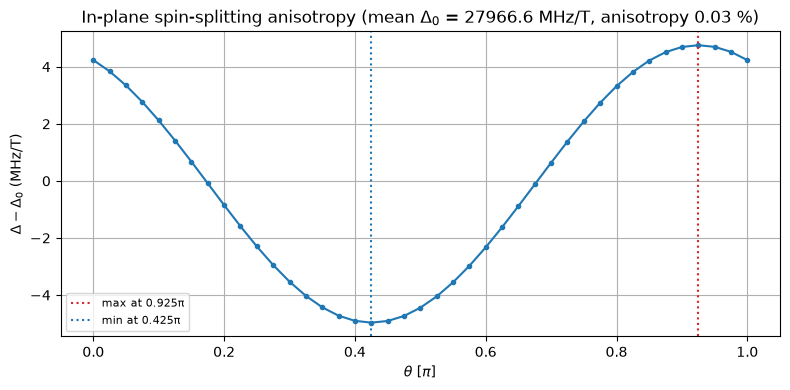


평균 spin-splitting: 27966.6 MHz/T
면내 각도에 대한 변동폭: 0.03 % (최대-최소 대비 평균)
최대 지점: theta=0.925pi, 최소 지점: theta=0.425pi, 위상차 0.500pi

[해석] 변동폭이 전체 평균의 1% 미만이면 이 FD-SOI 소자에서는 g-tensor가 면내 방향에 거의 등방적이라는 뜻입니다(1절 공식에서 g가 거의 등방 텐서). 변동이 뚜렷하면(수 % 이상) SOC로 인한 면내 비등방성이 실제로 의미 있는 크기라는 뜻이며, 최대/최소가 나타나는 각도 차이가 90도(0.5π)에 가까우면 g-tensor의 주축(principal axis)이 그 방향들과 정렬돼 있다는 뜻입니다. 이는 실험에서 자기장 방향에 따라 Rabi 주파수가 달라지는 정도와 직접 연결됩니다.


In [4]:
# [동작] in-plane g 데이터 로드 + 비등방성 정량화
g_data = np.loadtxt(FILE_G_TXT)
theta_pi, delta_mhz = g_data[0], g_data[1]

g_df = pd.DataFrame({"theta_over_pi": theta_pi, "splitting_MHz_per_T": delta_mhz})
display(g_df.describe())
g_df.to_csv(EXPORT_DIR / "in_plane_g_data.csv", index=False)

delta0 = delta_mhz.mean()
aniso_pct = (delta_mhz.max() - delta_mhz.min()) / delta0 * 100
theta_max = theta_pi[np.argmax(delta_mhz)]
theta_min = theta_pi[np.argmin(delta_mhz)]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(theta_pi, delta_mhz - delta0, "-o", ms=3)
ax.axvline(theta_max, color="tab:red", ls=":", label=f"max at {theta_max:.3f}π")
ax.axvline(theta_min, color="tab:blue", ls=":", label=f"min at {theta_min:.3f}π")
ax.set_xlabel(r"$\theta$ [$\pi$]")
ax.set_ylabel(r"$\Delta - \Delta_0$ (MHz/T)")
ax.set_title(f"In-plane spin-splitting anisotropy (mean $\\Delta_0$ = {delta0:.1f} MHz/T, "
            f"anisotropy {aniso_pct:.2f} %)")
ax.legend(fontsize=8); ax.grid(True)
fig.tight_layout()
fig.savefig(EXPORT_DIR / "in_plane_anisotropy.png", dpi=150)
plt.show()

print(f"\n평균 spin-splitting: {delta0:.1f} MHz/T")
print(f"면내 각도에 대한 변동폭: {aniso_pct:.2f} % (최대-최소 대비 평균)")
print(f"최대 지점: theta={theta_max:.3f}pi, 최소 지점: theta={theta_min:.3f}pi, "
      f"위상차 {abs(theta_max-theta_min):.3f}pi")
print(
    "\n[해석] 변동폭이 전체 평균의 1% 미만이면 이 FD-SOI 소자에서는 g-tensor가 면내 방향에 "
    "거의 등방적이라는 뜻입니다(1절 공식에서 g가 거의 등방 텐서). 변동이 뚜렷하면(수 % "
    "이상) SOC로 인한 면내 비등방성이 실제로 의미 있는 크기라는 뜻이며, 최대/최소가 나타나는 "
    "각도 차이가 90도(0.5π)에 가까우면 g-tensor의 주축(principal axis)이 그 방향들과 "
    "정렬돼 있다는 뜻입니다. 이는 실험에서 자기장 방향에 따라 Rabi 주파수가 달라지는 "
    "정도와 직접 연결됩니다."
)


## 3. g-Tensor 행렬 — 대각/비대각 성분 해석

g-tensor 행렬 자체는 `.txt`로 저장되지 않고 콘솔에만 출력되므로, 실행 로그
(`g_tensor_log_out6.txt`)에서 그대로 가져와 1절의 $\Delta E=g_\mathrm{eff}\mu_B B$ 식과
연결해 해석합니다.

In [5]:
# [점검] g-tensor 행렬 (실행 로그에서 파싱)
log_candidates = sorted(BASE_DIR.glob("g_tensor_log_out*.txt"))
g_matrix = None
for log_path in reversed(log_candidates):
    text = log_path.read_text(encoding="utf-8", errors="ignore")
    if "g = [[" in text and "Exiting QTCAD script" in text:
        block = text.split("g = [[", 1)[1].split("Average spin-splitting", 1)[0]
        nums = re.findall(r"[-+]?\d+\.\d+e[-+]\d+", block)
        vals = np.array(nums, dtype=float)
        n_complex = len(vals) // 2
        g_matrix = (vals[0::2] + 1j * vals[1::2])[:n_complex]
        n_rows = n_complex // 3
        g_matrix = g_matrix.reshape(n_rows, 3)
        print(f"[OK] {log_path.name}에서 g-tensor 파싱 성공 ({n_rows}x3)")
        break

if g_matrix is not None:
    display(pd.DataFrame(np.real(g_matrix)).round(6))
    diag = np.real(np.diag(g_matrix[-3:]))
    offdiag = np.real(g_matrix[-3:])[~np.eye(3, dtype=bool)]
    print(f"\n(마지막 3행 기준) 대각 성분: {diag}")
    print(f"대각 성분 평균: {diag.mean():.5f} (자유전자 g = 2.0023 대비 "
          f"{(diag.mean()-2.0023)/2.0023*100:+.3f} %)")
    print(f"비대각 성분 평균 크기: {np.abs(offdiag).mean():.5f} "
          f"(대각 대비 {np.abs(offdiag).mean()/diag.mean()*100:.3f} %)")
    pd.DataFrame(np.real(g_matrix)).to_csv(EXPORT_DIR / "g_tensor_matrix.csv", index=False)
else:
    print("[참고] 로그에서 g-tensor 행렬을 찾지 못했습니다.")

print(
    "\n[해석] 대각 성분이 자유전자 값(2.0023)에 가까우면 이 Si 기반 FD-SOI 전자 스핀의 "
    "g-factor는 SOC에 의한 보정이 작다는 뜻입니다(물리적으로 Si의 약한 SOC와 일치 — Ge, "
    "GaAs보다 원자번호가 작아 SOC가 약함). 비대각 성분이 대각 대비 1% 미만이면 g-tensor가 "
    "거의 대각(비등방 주축이 x,y,z 소자 축과 거의 일치)이라는 뜻이고, 그렇지 않으면 "
    "소자의 비대칭성(게이트 전압 분포, 계면 거칠기 등)이 스핀 양자화 축을 결정 축에서 "
    "비틀고 있다는 신호입니다."
)


[OK] g_tensor_log_out6.txt에서 g-tensor 파싱 성공 (4x3)


,0,1,2
0,0.000000,0.000000,-0.000000
1,1.998450,0.004279,0.000000
2,-0.004593,1.997831,0.000000
3,0.001579,-0.000451,2.004168



(마지막 3행 기준) 대각 성분: [1.99844964 1.9978306  2.0041679 ]
대각 성분 평균: 2.00015 (자유전자 g = 2.0023 대비 -0.107 %)
비대각 성분 평균 크기: 0.00182 (대각 대비 0.091 %)

[해석] 대각 성분이 자유전자 값(2.0023)에 가까우면 이 Si 기반 FD-SOI 전자 스핀의 g-factor는 SOC에 의한 보정이 작다는 뜻입니다(물리적으로 Si의 약한 SOC와 일치 — Ge, GaAs보다 원자번호가 작아 SOC가 약함). 비대각 성분이 대각 대비 1% 미만이면 g-tensor가 거의 대각(비등방 주축이 x,y,z 소자 축과 거의 일치)이라는 뜻이고, 그렇지 않으면 소자의 비대칭성(게이트 전압 분포, 계면 거칠기 등)이 스핀 양자화 축을 결정 축에서 비틀고 있다는 신호입니다.


## 4. $k_z^2$-SOC Hamiltonian과 SOC 유무 에너지 비교

`holes_soc_B.py`는 다음 형태의 유효 SOC 항을 Luttinger-Kohn 4-band Hamiltonian에
추가합니다 (소스 110-112행):
$$
H_{SOC} = \beta\langle k_z^2\rangle_0 \big(J_x\hat{B}_x^{(0)} - J_y\hat{B}_y^{(0)}\big),
\qquad \beta = 82\,e\,\text{Å}^3
$$
(바닥상태의 $\langle k_z^2\rangle_0$로 고정한 뒤 $J_x,J_y$ 각운동량 연산자에 결합 —
$k_z^2$은 얇은(3nm) 양자우물의 강한 구속에서 나오는 $z$방향 운동량의 기댓값으로,
우물이 얇을수록(5절) 이 SOC 결합이 커집니다). 자기장 $B_z=0\to10$T를 걸고 SOC를
껐을 때/켰을 때 10개 정공 에너지 준위가 어떻게 달라지는지 비교합니다.

,B_T,E0_noSOC_meV,E0_SOC_meV,diff_ueV
0,0.0,127.3881,127.2992,-88.8754
1,2.0,127.3272,127.1820,-145.1698
2,4.0,127.5751,127.3561,-218.9954
3,6.0,128.0565,127.7502,-306.2861
4,8.0,128.6760,128.2739,-402.0802
5,10.0,129.3563,128.8548,-501.5511



유효 g-factor (E1-E0 기울기, SOC 없음): 0.490
유효 g-factor (E1-E0 기울기, SOC 있음) : 0.129
SOC로 인한 g-factor 변화               : -73.74 %


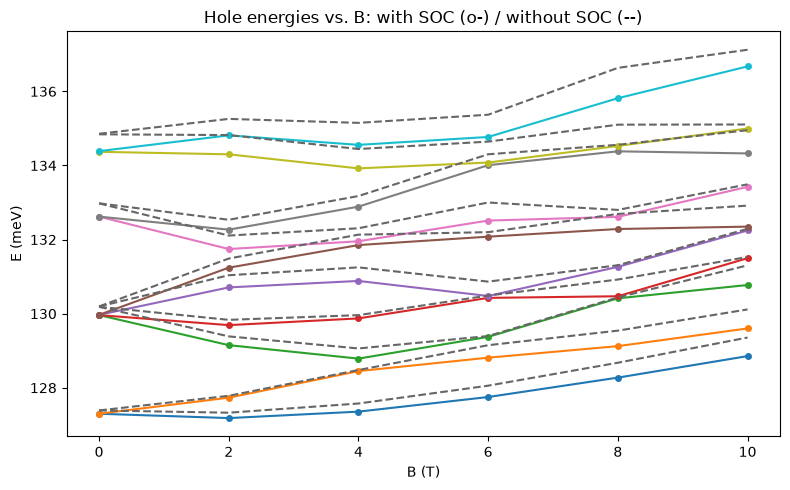


[해석] 바닥상태(E0) 기준으로 SOC를 켰을 때와 껐을 때의 에너지 차이가 B=0에서도 0이 아니면, 이 SOC 모델이 자기장과 무관하게도 준위를 갈라놓는다는 뜻입니다. 유효 g-factor가 SOC 유무로 달라지면(위 수치), SOC가 단순히 준위를 이동시키는 것을 넘어 자기장에 대한 반응(Zeeman 기울기) 자체를 바꾸고 있다는 뜻 — 이것이 바로 'SOC가 g-tensor를 renormalize한다'는 현상의 가장 단순한 예시입니다.


In [6]:
# [동작] SOC 유무 에너지 데이터 로드
E_nosoc = np.loadtxt(FILE_E_NOSOC)
E_soc = np.loadtxt(FILE_E_SOC)
B_field = E_nosoc[:, 0]

e0_df = pd.DataFrame({
    "B_T": B_field, "E0_noSOC_meV": E_nosoc[:, 1] * 1e3, "E0_SOC_meV": E_soc[:, 1] * 1e3,
    "diff_ueV": (E_soc[:, 1] - E_nosoc[:, 1]) * 1e6,
})
display(e0_df.round(4))
e0_df.to_csv(EXPORT_DIR / "soc_energy_comparison.csv", index=False)

# effective g-factor from no-SOC and SOC Zeeman slope (E1-E0 as proxy)
split_nosoc = (E_nosoc[:, 2] - E_nosoc[:, 1]) * ct_e  # J
split_soc = (E_soc[:, 2] - E_soc[:, 1]) * ct_e
g_nosoc = np.polyfit(B_field[1:], split_nosoc[1:] / mu_B, 1)[0]
g_soc = np.polyfit(B_field[1:], split_soc[1:] / mu_B, 1)[0]
print(f"\n유효 g-factor (E1-E0 기울기, SOC 없음): {g_nosoc:.3f}")
print(f"유효 g-factor (E1-E0 기울기, SOC 있음) : {g_soc:.3f}")
print(f"SOC로 인한 g-factor 변화               : {(g_soc-g_nosoc)/g_nosoc*100:+.2f} %")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(B_field, E_soc[:, 1:] * 1e3, "o-", ms=4)
ax.plot(B_field, E_nosoc[:, 1:] * 1e3, "--", color="0.4")
ax.set_xlabel("B (T)"); ax.set_ylabel("E (meV)")
ax.set_title("Hole energies vs. B: with SOC (o-) / without SOC (--)")
fig.tight_layout()
fig.savefig(EXPORT_DIR / "soc_energy_vs_B.png", dpi=150)
plt.show()

print(
    "\n[해석] 바닥상태(E0) 기준으로 SOC를 켰을 때와 껐을 때의 에너지 차이가 B=0에서도 "
    "0이 아니면, 이 SOC 모델이 자기장과 무관하게도 준위를 갈라놓는다는 뜻입니다. 유효 "
    "g-factor가 SOC 유무로 달라지면(위 수치), SOC가 단순히 준위를 이동시키는 것을 넘어 "
    "자기장에 대한 반응(Zeeman 기울기) 자체를 바꾸고 있다는 뜻 — 이것이 바로 "
    "'SOC가 g-tensor를 renormalize한다'는 현상의 가장 단순한 예시입니다."
)


## 5. $\langle k_z^2\rangle$ — 수치 vs 해석값

무한 우물 바닥상태의 해석적 파동함수 $\psi_0(z)=\sqrt{2/L_z}\sin(\pi z/L_z)$로부터
$$
\langle k_z^2 \rangle_\mathrm{analytic} = \left(\frac{\pi}{L_z}\right)^2
$$
($L_z=3$nm인 이 박스 기준). TB/k·p 수치해와 비교합니다.

,state,kz2_nm-2
0,0,1.0614
1,1,1.0615
2,2,1.0617
3,3,1.0646
4,4,1.0648
5,5,1.0620
6,6,1.0650
7,7,1.0625
8,8,1.0653
9,9,1.0658


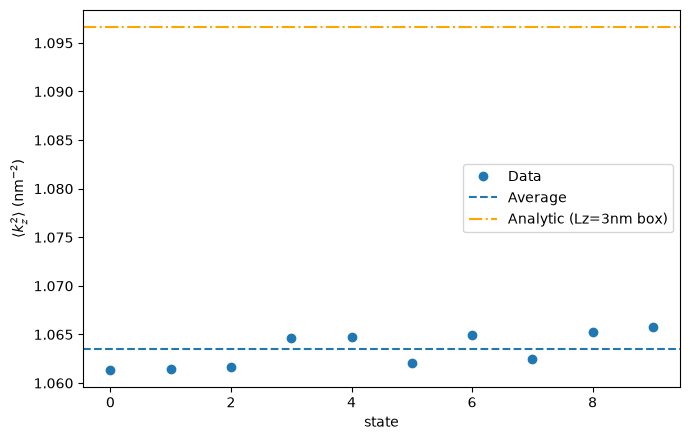


수치 평균: 1.0635 nm^-2, 해석값: 1.0966 nm^-2 (편차 -3.02 %)

[해석] 편차가 작으면(수 % 이내) 유한요소 메시가 z방향 구속을 충분히 잘 표현한다는 뜻이고, 상태별 값이 거의 일정하면 10개 상태 모두가 같은 z방향 바닥상태 준위에서 x-y 방향으로만 다른 궤도(란다우 준위류)라는 뜻입니다. 4절 SOC Hamiltonian의 결합세기가 바로 이 <kz^2>에 비례하므로, 이 수치 검증이 4절 결과의 신뢰도를 뒷받침합니다.


In [7]:
# [점검] kz^2 수치 vs 해석값
kz2 = np.loadtxt(FILE_KZ2_TXT)
nm = 1e-9
Lz = 3 * nm
kz2_analytic = (np.pi / Lz) ** 2

kz2_df = pd.DataFrame({"state": range(len(kz2)), "kz2_nm-2": kz2 * nm**2})
display(kz2_df.round(4))
kz2_df.to_csv(EXPORT_DIR / "kz2_comparison.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(kz2 * nm**2, "o", label="Data")
ax.axhline(kz2.mean() * nm**2, ls="--", label="Average")
ax.axhline(kz2_analytic * nm**2, ls="-.", color="orange", label="Analytic (Lz=3nm box)")
ax.set_xlabel("state"); ax.set_ylabel(r"$\langle k_z^2 \rangle$ (nm$^{-2}$)")
ax.legend()
fig.tight_layout()
fig.savefig(EXPORT_DIR / "kz2_vs_analytic.png", dpi=150)
plt.show()

dev_pct = (kz2.mean() - kz2_analytic) / kz2_analytic * 100
print(f"\n수치 평균: {kz2.mean()*nm**2:.4f} nm^-2, 해석값: {kz2_analytic*nm**2:.4f} nm^-2 "
      f"(편차 {dev_pct:+.2f} %)")
print(
    "\n[해석] 편차가 작으면(수 % 이내) 유한요소 메시가 z방향 구속을 충분히 잘 표현한다는 "
    "뜻이고, 상태별 값이 거의 일정하면 10개 상태 모두가 같은 z방향 바닥상태 준위에서 "
    "x-y 방향으로만 다른 궤도(란다우 준위류)라는 뜻입니다. 4절 SOC Hamiltonian의 "
    "결합세기가 바로 이 <kz^2>에 비례하므로, 이 수치 검증이 4절 결과의 신뢰도를 뒷받침합니다."
)


## 6. 최종 요약

In [8]:
# [점검] 핵심 결과 요약
print("=" * 92)
print("QTCAD M09 g-tensor — ANALYSIS SUMMARY (심화판)")
print("=" * 92)
print(f"Average in-plane spin-splitting   : {delta0:.1f} MHz/T")
print(f"In-plane anisotropy (max-min/mean) : {aniso_pct:.2f} %")
if g_matrix is not None:
    print(f"g-tensor diagonal (mean)           : {diag.mean():.5f} (free-electron 2.0023 대비 "
          f"{(diag.mean()-2.0023)/2.0023*100:+.3f} %)")
    print(f"g-tensor off-diagonal (mean |.|)   : {np.abs(offdiag).mean():.5f}")
print(f"holes_soc_B: g_eff (no-SOC / SOC)   : {g_nosoc:.3f} / {g_soc:.3f} "
      f"({(g_soc-g_nosoc)/g_nosoc*100:+.2f} %)")
print(f"kz^2 numeric vs analytic deviation  : {dev_pct:+.2f} %")
print(f"Analysis exports                    : {EXPORT_DIR}")
print("=" * 92)


QTCAD M09 g-tensor — ANALYSIS SUMMARY (심화판)
Average in-plane spin-splitting   : 27966.6 MHz/T
In-plane anisotropy (max-min/mean) : 0.03 %
g-tensor diagonal (mean)           : 2.00015 (free-electron 2.0023 대비 -0.107 %)
g-tensor off-diagonal (mean |.|)   : 0.00182
holes_soc_B: g_eff (no-SOC / SOC)   : 0.490 / 0.129 (-73.74 %)
kz^2 numeric vs analytic deviation  : -3.02 %
Analysis exports                    : C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M09. g-tensor\Reference\output\analysis_exports


## 해석 주의사항

- `g_tensor.py`의 원자 박스(x,y,z ±120/±220~-130/±60~10 Å)는 메모리 문제로 원래 튜토리얼
  (269,934개 원자)보다 축소(76,917개)됐습니다. 물리적 영역(소자 아래 플런저 게이트 영역)은
  유지했으나 원래 크기와 정확히 같지는 않습니다 — `notes.md`에 재현성(계산 시간 편차) 문제도
  같이 기록했습니다.
- `holes_soc_B.py`는 작은 GaAs 박스 + 해석적 SOC 결합 상수(β)를 쓰는 별도의 단순화된
  모델입니다. `g_tensor.py`의 FD-SOI 전자 g-tensor와는 재질(GaAs 정공 vs Si 전자)과
  모델이 다르므로 직접 비교하지 말고, 'SOC가 에너지 준위/스핀에 미치는 영향의 정성적 패턴'을
  보는 용도로만 사용해야 합니다.
- g-tensor 행렬은 `.txt`로 저장되지 않아 실행 로그에서 정규식으로 파싱했습니다 — 로그
  파일이 삭제되거나 형식이 바뀌면 이 파싱이 깨질 수 있습니다.
